In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load profit data
df = pd.read_csv("ex1data1.csv", header=None)
df.rename(columns={0: 'population', 1: 'profit'}, inplace=True)
df.head()

,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


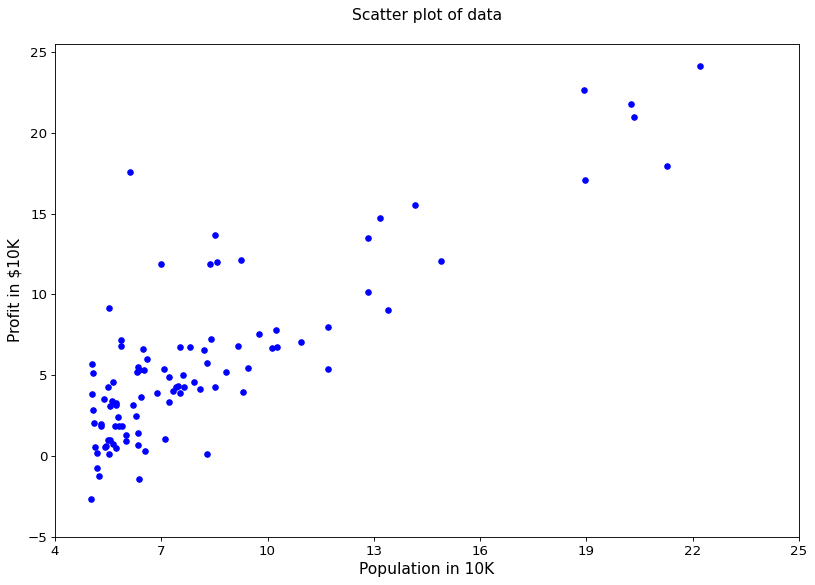

In [2]:
# Visualize the data
fig = plt.figure(num=None, figsize=(12, 8), dpi=80, facecolor='w')
plt.scatter(df['population'], df['profit'], marker='o', color='blue', s=24,label='data')
plt.xlim([4, 25])
plt.xticks(range(4, 26, 3), size=12)
plt.yticks(range(-5, 30, 5), size=12)
plt.xlabel("Population in 10K", size=14)
plt.ylabel("Profit in $10K", size=14)
plt.title("Scatter plot of data\n", size=14)

#X=df['population']
#Y=df['profit']
#w=np.array([0,1])

#prediction= X*w[1]+w[0]
#plt.scatter(X,prediction,label='Prediction')
#plt.legend()

plt.show()



In [3]:
class LinearRegression(object):
    def __init__(self, X, y, alpha=0.01, n_iterations=250):
        self.X = np.hstack((np.ones((X.shape[0], 1)), X))
        self.y = y
        self.weight = np.zeros((self.X.shape[1], 1))
        self.num_rows = self.X.shape[0]
        self.alpha = alpha
        self.num_iterations = n_iterations
        
    def predict(self, Xtest):
        # Why do we do this?
        Xtest = np.hstack((np.ones((Xtest.shape[0], 1)), Xtest))
        
        return Xtest.dot(self.weight)

    def compute_gradient(self, ):
        diff = self.X.dot(self.weight) - self.y
        grad = np.multiply(self.X, diff)
        grad = np.mean(grad, axis=0)
        return grad.reshape(-1, 1)
    
    def gradient_descent(self, ):
        loss_ts=[]
        for i in range(self.num_iterations):
            self.weight = self.weight - self.alpha * self.compute_gradient()
            loss = np.mean((self.X.dot(self.weight) - self.y) ** 2)
            if i % 5 == 0:
                print("Iteration: {0} Loss: {1:.5f}\r".format(i + 1, loss))
            loss_ts.append(loss)
        return loss_ts

In [4]:
X = df['population'].values.reshape(-1, 1)
y = df['profit'].values.reshape(-1, 1)
alpha = .01
linear_regression = LinearRegression(X, y, alpha)
loss_ts=linear_regression.gradient_descent()

Iteration: 1 Loss: 13.47438
Iteration: 6 Loss: 11.77001
Iteration: 11 Loss: 11.71966
Iteration: 16 Loss: 11.67020
Iteration: 21 Loss: 11.62164
Iteration: 26 Loss: 11.57394
Iteration: 31 Loss: 11.52709
Iteration: 36 Loss: 11.48108
Iteration: 41 Loss: 11.43589
Iteration: 46 Loss: 11.39152
Iteration: 51 Loss: 11.34793
Iteration: 56 Loss: 11.30513
Iteration: 61 Loss: 11.26309
Iteration: 66 Loss: 11.22180
Iteration: 71 Loss: 11.18125
Iteration: 76 Loss: 11.14142
Iteration: 81 Loss: 11.10231
Iteration: 86 Loss: 11.06389
Iteration: 91 Loss: 11.02617
Iteration: 96 Loss: 10.98912
Iteration: 101 Loss: 10.95273
Iteration: 106 Loss: 10.91699
Iteration: 111 Loss: 10.88189
Iteration: 116 Loss: 10.84741
Iteration: 121 Loss: 10.81356
Iteration: 126 Loss: 10.78031
Iteration: 131 Loss: 10.74765
Iteration: 136 Loss: 10.71558
Iteration: 141 Loss: 10.68408
Iteration: 146 Loss: 10.65314
Iteration: 151 Loss: 10.62276
Iteration: 156 Loss: 10.59292
Iteration: 161 Loss: 10.56362
Iteration: 166 Loss: 10.53484
It

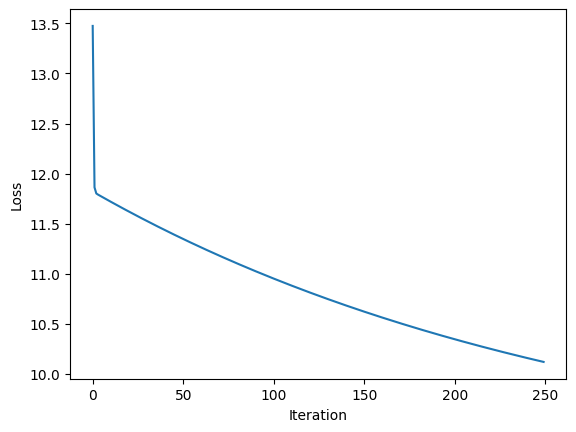

In [5]:
plt.plot(loss_ts)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

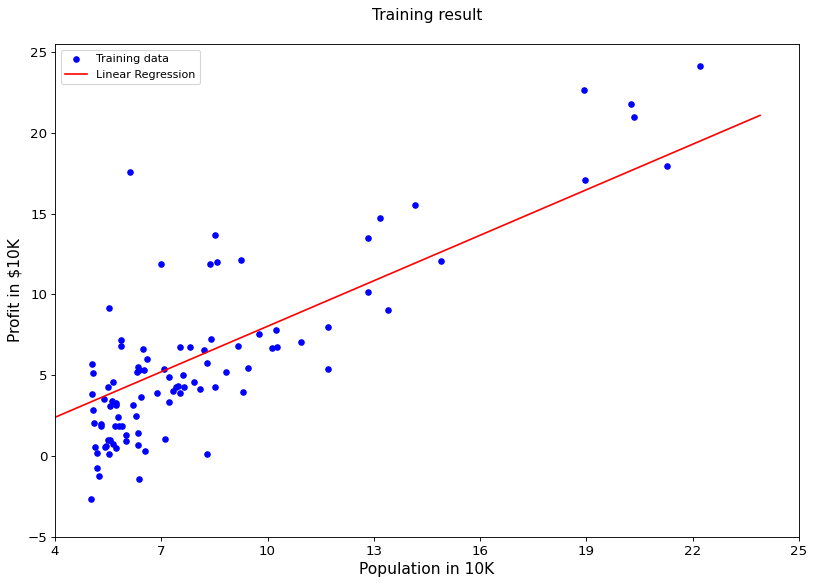

In [6]:
# plot regression line
X = np.arange(4, 24, 0.1).reshape(-1, 1)
fig = plt.figure(num=None, figsize=(12, 8), dpi=80, facecolor='w')
plt.scatter(df['population'], df['profit'], marker='o', color='blue', s=24, label='Training data')
plt.plot(X, linear_regression.predict(X), color='red', label='Linear Regression')
plt.xlim([4, 25])
plt.xticks(range(4, 26, 3), size=12)
plt.yticks(range(-5, 30, 5), size=12)
plt.xlabel("Population in 10K", size=14)
plt.ylabel("Profit in $10K", size=14)
plt.title("Training result\n", size=14)
plt.legend()
plt.show()

In [7]:
# Linear regression with multiple variables
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("ex1data2.csv", header=None)
df.rename(columns={0: 'size', 1: 'bedrooms',2:'price'}, inplace=True)

df.head()

,size,bedrooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [8]:
X = df.iloc[:, [0, 1]].values
y = df.iloc[:, [2]].values

#What happens if we don't do this?
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

learner = LinearRegression(X, y, alpha=.00002, n_iterations=500)

learner.gradient_descent()
X_test = np.array([2104, 3]).reshape(1, 2)
X_test = scaler_X.transform(X_test)
prediction = learner.predict(X_test)
print("Prediction (Unscaled): {0:.2f}".format(scaler_y.inverse_transform(prediction)[0][0]))


Iteration: 1 Loss: 0.99996
Iteration: 6 Loss: 0.99978
Iteration: 11 Loss: 0.99959
Iteration: 16 Loss: 0.99941
Iteration: 21 Loss: 0.99922
Iteration: 26 Loss: 0.99904
Iteration: 31 Loss: 0.99885
Iteration: 36 Loss: 0.99867
Iteration: 41 Loss: 0.99848
Iteration: 46 Loss: 0.99830
Iteration: 51 Loss: 0.99811
Iteration: 56 Loss: 0.99793
Iteration: 61 Loss: 0.99774
Iteration: 66 Loss: 0.99756
Iteration: 71 Loss: 0.99737
Iteration: 76 Loss: 0.99719
Iteration: 81 Loss: 0.99700
Iteration: 86 Loss: 0.99682
Iteration: 91 Loss: 0.99664
Iteration: 96 Loss: 0.99645
Iteration: 101 Loss: 0.99627
Iteration: 106 Loss: 0.99608
Iteration: 111 Loss: 0.99590
Iteration: 116 Loss: 0.99572
Iteration: 121 Loss: 0.99553
Iteration: 126 Loss: 0.99535
Iteration: 131 Loss: 0.99516
Iteration: 136 Loss: 0.99498
Iteration: 141 Loss: 0.99480
Iteration: 146 Loss: 0.99461
Iteration: 151 Loss: 0.99443
Iteration: 156 Loss: 0.99424
Iteration: 161 Loss: 0.99406
Iteration: 166 Loss: 0.99388
Iteration: 171 Loss: 0.99369
Iterati

In [9]:
X.shape

(47, 2)

In [10]:
learner.weight

array([[-8.10746269e-19],
       [ 8.49512132e-03],
       [ 4.37690584e-03]])

In [11]:
df['pred']=scaler_y.inverse_transform(learner.predict(X))

Text(0, 0.5, 'prediction')

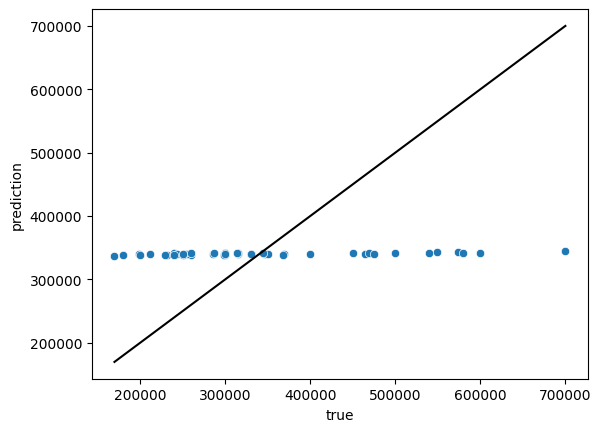

In [12]:
import seaborn as sns
sns.scatterplot(df,x='price',y='pred')
plt.plot([df['price'].min(),df['price'].max()],[df['price'].min(),df['price'].max()],color='black')
plt.xlabel('true')
plt.ylabel('prediction')

In [13]:
# Lots of ways to do matrix multiplication!

In [14]:
print('Data Shape',X.shape)
print('Weight Shape',learner.weight.shape)
X_w_intercept=np.hstack( [np.ones((X.shape[0],1)),X])

print(X_w_intercept.shape)

one=X_w_intercept.dot(learner.weight)
two=(X_w_intercept@learner.weight)
three=np.dot(X_w_intercept,learner.weight)
four=np.matmul(X_w_intercept,learner.weight)
five=(X_w_intercept*learner.weight.T).sum(axis=1,keepdims=True)

print((one==two).all(),
(two==three).all(),
(three==four).all(),
(four==five).all())
print(np.isclose(four,five).all())

Data Shape (47, 2)
Weight Shape (3, 1)
(47, 3)
True True True False
True


# latex in markdown!
$\alpha=0.001 \begin{pmatrix}w_0 \\ w_1 \end{pmatrix}$